In [55]:
# ============================================================================
# FIG 5: cross-experiment VIB predictions, naive/KNN-based synthetic perturbation
# simulation, and latent-space entropy analysis, for the Z2 (MEKi/WntSeci) and X7
# (LATSi) perturbation experiments, evaluated against a VIB model trained only on
# Exp20 control (B50) data.
# ============================================================================

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches
import time
import os
import sys
import torch
from skimage import io as imio
import torch.optim as optim
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

sys.path.append('2D_gastruloids_v5')
import fns_plotting_scripts as fns_plot
import fns_NN
import IIF_analysis as IIF

import importlib
importlib.reload(IIF);

In [41]:
# Set up per-experiment configuration and load Exp20 (control reference), Z2, and
# X7 (real perturbation experiments) into ExperimentResults objects. Each exposes:
#   .data       raw per-cell measurements
#   .data_z     z-scored against THIS experiment's own B50 controls -- needed because
#               raw intensity isn't directly comparable across imaging sessions, but
#               z-scored signals are, which is what makes cross-experiment VIB
#               training/prediction meaningful
#   .thresh     per-gene fate-marker positivity threshold, in RAW intensity units,
#               manually calibrated separately for each experiment (see note below)
#   .gene_names, .signal_names, .col/.exp (Colony/Experiment objects)
# Z2 and X7 only measured a 7-gene subset of Exp20's 16 genes.

dataDir = '/Users/idse/data_tmp/signaldecoding/'

# Load all three datasets
config = IIF.ExperimentConfig(
    exp_params = {
        'Z2': (dataDir+'250930_Perturbation6i_MEKi_WntSeci', 'expZ2_data_scaled_bgsub_6_cols_251002.csv',
               {'SOX17_1': 'SOX17', 'TBX6_2': 'TBX6', 'SOX2_2': 'SOX2', 'DAPI_1': 'DAPI'},
               ['B50', 'B50I5', 'B50SB10', 'B50M0p5'],
               {'ISL1': 200, 'TFAP2C': 350, 'SOX17': 200, 'NANOG': 800, 'TBX6': 300, 'TBXT': 175, 'SOX2': 150},
               'expZ2_junk_labels_nans_removed.csv'),
        'X7': (dataDir+'250909_Perturbation6i_LATSi', 'expX7_data_scaled_bgsub_4_cols_250909.csv',
               {'SOX17_1': 'SOX17', 'DAPI_1': 'DAPI'},
               ['B50', 'B50T30'],
               {'ISL1': 150, 'TFAP2C': 400, 'SOX17': 200, 'NANOG': 600, 'TBX6': 400, 'TBXT': 175, 'SOX2': 250},
               None),
        '20': (dataDir + 'data_BMPdoses/data', 'exp20_data_bgsub_scaled_250509.csv',
               {'SOX17_1': 'SOX17', 'DAPI_1': 'DAPI'},
               ['B50', 'B200', 'B10'],
               {'ISL1': 500, 'GATA3': 700, 'HAND1': 500, 'CDX2': 600, 'TFAP2C': 600, 'SOX17': 500, 'PRDM1': 650,
                'SNAI1': 300, 'MIXL1': 400, 'EOMES': 200, 'TBXT': 285, 'TBX6': 375, 'OCT4': 500, 'NANOG': 1600,
                'SOX2': 400, 'OTX2': 400},
               None),
    },
    signal_names  = ['pSMAD1', 'ncYAP', 'BCat', 'LEF1', 'ncSMAD23', 'cytopERK'],
    feature_names = ['nucArea', 'nucVolume', 'nucMajorAxis', 'nucMinorAxis',
                     'nucCircularity', 'CircleEdgeDist', 'RadialDist']
)


exp_result_20 = IIF.ExperimentResults('20', config)
exp_result_Z2 = IIF.ExperimentResults('Z2', config)
exp_result_X7 = IIF.ExperimentResults('X7', config)

B50, Nbins = 609
B200, Nbins = 576
B10, Nbins = 503
B50, Nbins = 609
B200, Nbins = 576
B10, Nbins = 503
B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
B50, Nbins = 544
B50T30, Nbins = 340
B50, Nbins = 544
B50T30, Nbins = 340


In [15]:
# MODEL BACKGROUND (NEGATIVE) AND FOREGROUND (POSITIVE) POPULATIONS VIA KDE MODE + HWHM SIGMA
# per marker, for a given experiment's B50 condition -- ported from the fig2n.ipynb threshold work.
# No model predictions used anywhere in this cell.

from scipy.stats import gaussian_kde, norm
from scipy.signal import find_peaks

EXP_RESULT = exp_result_X7   # change to exp_result_X7 to rerun for the other dataset
EXP_LABEL = 'X7'             # matches EXP_RESULT, used for filenames
FOREGROUND_MARKERS = {'NANOG'}   # pluripotency markers not in the 20-gene panel here; OCT4 isn't measured

data_cond = EXP_RESULT.data[EXP_RESULT.data['condition'] == 'B50']
gene_names_exp = EXP_RESULT.gene_names
thresh_exp = EXP_RESULT.thresh

BANDWIDTH_SCALE = 1
PEAK_PROMINENCE_FRAC = 0.00
PEAK_HEIGHT_FRAC = 0.01

GAUSSIAN_HWHM_TO_SIGMA = np.sqrt(2 * np.log(2))

def log_transform(values):
    min_val = np.min(values)
    offset = 0.0 if min_val > 0 else (1.0 - min_val)
    return np.log10(values + offset), offset

def background_mode(log_vals, n_grid=1000):
    kde_default = gaussian_kde(log_vals)
    bw = kde_default.scotts_factor() * BANDWIDTH_SCALE
    kde = gaussian_kde(log_vals, bw_method=bw)

    grid = np.linspace(log_vals.min(), log_vals.max(), n_grid)
    density = kde(grid)

    peak_idx, _ = find_peaks(density,
                              prominence=PEAK_PROMINENCE_FRAC * density.max(),
                              height=PEAK_HEIGHT_FRAC * density.max())
    if len(peak_idx) == 0:
        peak_idx = np.array([np.argmax(density)])

    peak_x = grid[peak_idx]
    m_lowest = peak_x.min()
    return m_lowest, peak_x, grid, density

def left_hwhm_sigma(grid, density, m):
    peak_idx = np.argmin(np.abs(grid - m))
    peak_height = density[peak_idx]
    half_height = 0.5 * peak_height
    idx = peak_idx
    while idx > 0 and density[idx] >= half_height:
        idx -= 1
    if idx == peak_idx or (idx == 0 and density[0] >= half_height):
        return np.nan
    x0, x1 = grid[idx], grid[idx+1]
    y0, y1 = density[idx], density[idx+1]
    x_cross = x0 + (half_height - y0) * (x1 - x0) / (y1 - y0)
    hwhm = m - x_cross
    return hwhm / GAUSSIAN_HWHM_TO_SIGMA

def right_hwhm_sigma(grid, density, m):
    peak_idx = np.argmin(np.abs(grid - m))
    peak_height = density[peak_idx]
    half_height = 0.5 * peak_height
    idx = peak_idx
    while idx < len(grid) - 1 and density[idx] >= half_height:
        idx += 1
    if idx == peak_idx or (idx == len(grid) - 1 and density[-1] >= half_height):
        return np.nan
    x0, x1 = grid[idx-1], grid[idx]
    y0, y1 = density[idx-1], density[idx]
    x_cross = x0 + (half_height - y0) * (x1 - x0) / (y1 - y0)
    hwhm = x_cross - m
    return hwhm / GAUSSIAN_HWHM_TO_SIGMA

def posterior_crossing(grid, density, m, sigma, w, cutoff, direction):
    model_density = w * norm.pdf(grid, m, sigma)
    with np.errstate(divide='ignore', invalid='ignore'):
        frac = np.where(density > 0, model_density / density, np.nan)
    frac = np.clip(frac, 0, 1)
    peak_idx = np.argmin(np.abs(grid - m))
    idx = peak_idx
    if direction > 0:
        while idx < len(grid) - 1 and frac[idx] >= cutoff:
            idx += 1
        if idx == peak_idx or frac[idx] >= cutoff:
            return np.nan
        x0, x1 = grid[idx-1], grid[idx]
        y0, y1 = frac[idx-1], frac[idx]
    else:
        while idx > 0 and frac[idx] >= cutoff:
            idx -= 1
        if idx == peak_idx or frac[idx] >= cutoff:
            return np.nan
        x0, x1 = grid[idx], grid[idx+1]
        y0, y1 = frac[idx], frac[idx+1]
    return x0 + (cutoff - y0) * (x1 - x0) / (y1 - y0)

def equal_posterior_crossing(grid, m, sigma_bg, w_bg, m_high, sigma_fg, w_fg):
    mask = (grid >= m) & (grid <= m_high)
    sub_grid = grid[mask]
    bg = w_bg * norm.pdf(sub_grid, m, sigma_bg)
    fg = w_fg * norm.pdf(sub_grid, m_high, sigma_fg)
    diff = bg - fg
    sign_change = np.where(np.diff(np.sign(diff)) != 0)[0]
    if len(sign_change) == 0:
        return np.nan
    idx = sign_change[0]
    x0, x1 = sub_grid[idx], sub_grid[idx+1]
    y0, y1 = diff[idx], diff[idx+1]
    return x0 - y0 * (x1 - x0) / (y1 - y0)

BACKGROUND_POSTERIOR_CUTOFF = 0.05
FOREGROUND_POSTERIOR_CUTOFF = 0.5

fits = {}
thresh_auto = {}

for marker in gene_names_exp:

    values = data_cond[marker].to_numpy()
    values = values[~np.isnan(values)]

    log_vals, offset = log_transform(values)
    m_lowest, all_modes, grid, density = background_mode(log_vals)
    n_modes = len(all_modes)

    if marker in FOREGROUND_MARKERS and n_modes == 1:
        m = np.nan
        sigma_hwhm = np.nan
        m_high = all_modes.max()
        sigma_hwhm_high = right_hwhm_sigma(grid, density, m_high)
    else:
        m = m_lowest
        sigma_hwhm = left_hwhm_sigma(grid, density, m)
        has_foreground = n_modes >= 2
        m_high = all_modes.max() if has_foreground else np.nan
        sigma_hwhm_high = right_hwhm_sigma(grid, density, m_high) if has_foreground else np.nan

    fits[marker] = dict(m=m, all_modes=all_modes, offset=offset, sigma_hwhm=sigma_hwhm,
                         m_high=m_high, sigma_hwhm_high=sigma_hwhm_high,
                         n_modes=n_modes, log_vals=log_vals, grid=grid, density=density)

    has_bg = not np.isnan(sigma_hwhm)
    has_fg = not np.isnan(sigma_hwhm_high)

    if marker in FOREGROUND_MARKERS and has_fg:
        w = 2 * np.mean(log_vals > m_high)
        x_cross = posterior_crossing(grid, density, m_high, sigma_hwhm_high, w, FOREGROUND_POSTERIOR_CUTOFF, direction=-1)
    elif has_bg and has_fg:
        w_bg = 2 * np.mean(log_vals < m)
        w_fg = 2 * np.mean(log_vals > m_high)
        x_cross = equal_posterior_crossing(grid, m, sigma_hwhm, w_bg, m_high, sigma_hwhm_high, w_fg)
    elif has_fg:
        w = 2 * np.mean(log_vals > m_high)
        x_cross = posterior_crossing(grid, density, m_high, sigma_hwhm_high, w, FOREGROUND_POSTERIOR_CUTOFF, direction=-1)
    elif has_bg:
        w = 2 * np.mean(log_vals < m)
        x_cross = posterior_crossing(grid, density, m, sigma_hwhm, w, BACKGROUND_POSTERIOR_CUTOFF, direction=1)
    else:
        x_cross = np.nan

    thresh_auto[marker] = 10**x_cross - offset if not np.isnan(x_cross) else np.nan

missing = [mk for mk, t in thresh_auto.items() if np.isnan(t)]
if missing:
    print(f"WARNING: no automated threshold found for: {missing}")

threshold_comparison_exp = pd.DataFrame({
    'manual_threshold': pd.Series(thresh_exp),
    'automated_threshold': pd.Series(thresh_auto),
})
threshold_comparison_exp['ratio'] = threshold_comparison_exp['automated_threshold'] / threshold_comparison_exp['manual_threshold']
threshold_comparison_exp


,manual_threshold,automated_threshold,ratio
ISL1,150,193.543067,1.290287
TFAP2C,400,283.615504,0.709039
SOX17,200,123.267313,0.616337
NANOG,600,696.733071,1.161222
TBX6,400,470.188710,1.175472
TBXT,175,185.022601,1.057272
SOX2,250,524.808506,2.099234


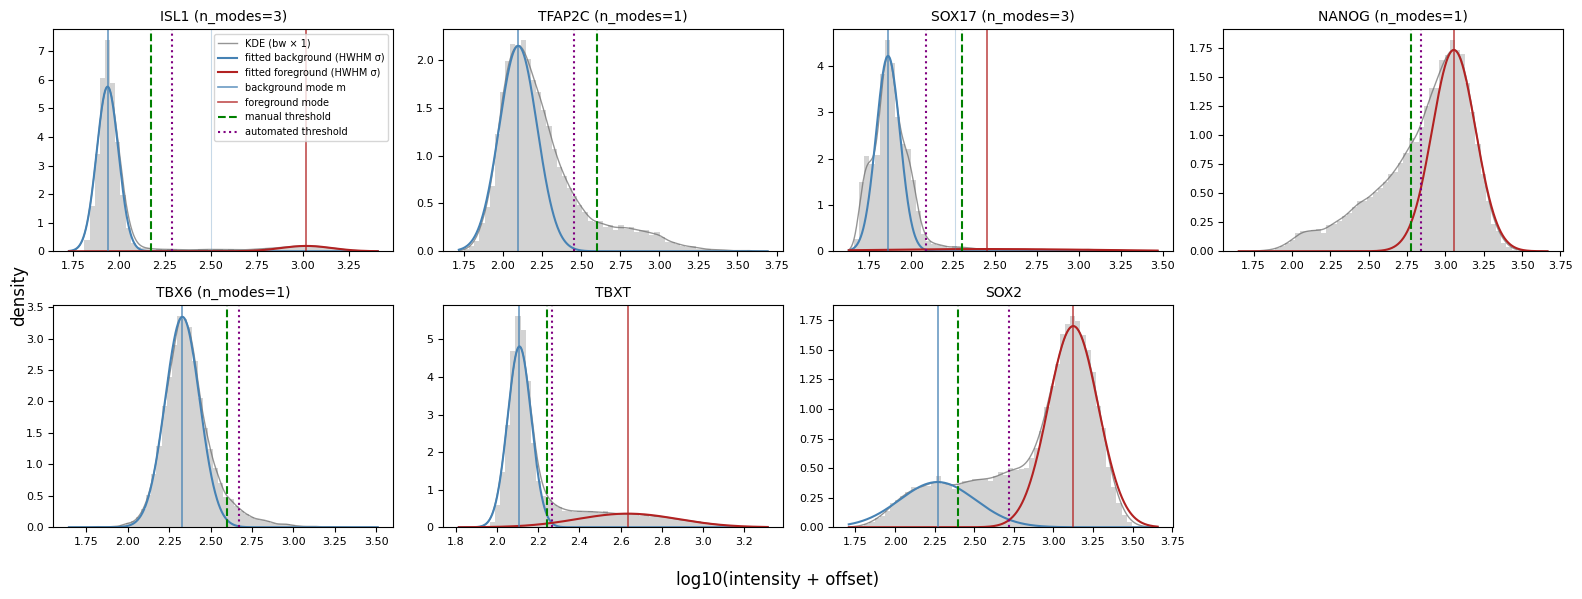

In [16]:
# PLOT BACKGROUND/FOREGROUND MODEL AND THRESHOLDS, PER MARKER

n_genes = len(gene_names_exp)
n_cols = 4
n_rows = int(np.ceil(n_genes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = np.array(axes).reshape(-1)

for i, marker in enumerate(gene_names_exp):

    fit = fits[marker]
    x_grid = fit['grid']

    ax = axes[i]
    ax.hist(fit['log_vals'], bins=60, density=True, color='lightgray', edgecolor='none')
    ax.plot(x_grid, fit['density'], color='dimgray', linewidth=1, alpha=0.7, label=f'KDE (bw × {BANDWIDTH_SCALE:.2g})')

    if not np.isnan(fit['sigma_hwhm']):
        bg_peak_height = fit['density'][np.argmin(np.abs(x_grid - fit['m']))]
        bg_pdf = norm.pdf(x_grid, fit['m'], fit['sigma_hwhm'])
        bg_pdf_scaled = bg_pdf * (bg_peak_height / bg_pdf.max())
        ax.plot(x_grid, bg_pdf_scaled, color='steelblue', label='fitted background (HWHM σ)')

    if not np.isnan(fit['sigma_hwhm_high']):
        fg_peak_height = fit['density'][np.argmin(np.abs(x_grid - fit['m_high']))]
        fg_pdf = norm.pdf(x_grid, fit['m_high'], fit['sigma_hwhm_high'])
        fg_pdf_scaled = fg_pdf * (fg_peak_height / fg_pdf.max())
        ax.plot(x_grid, fg_pdf_scaled, color='firebrick', label='fitted foreground (HWHM σ)')

    for mode_x in fit['all_modes']:
        if mode_x == fit['m'] or mode_x == fit['m_high']:
            continue
        ax.axvline(mode_x, color='steelblue', linewidth=0.8, alpha=0.3)

    if not np.isnan(fit['m']):
        ax.axvline(fit['m'], color='steelblue', linewidth=1.2, alpha=0.8, label='background mode m')
    if not np.isnan(fit['m_high']):
        ax.axvline(fit['m_high'], color='firebrick', linewidth=1.2, alpha=0.8, label='foreground mode')

    manual_log = np.log10(thresh_exp[marker] + fit['offset'])
    ax.axvline(manual_log, color='green', linestyle='--', linewidth=1.5, label='manual threshold')

    auto_thresh = thresh_auto[marker]
    if not np.isnan(auto_thresh):
        auto_log = np.log10(auto_thresh + fit['offset'])
        ax.axvline(auto_log, color='purple', linestyle=':', linewidth=1.5, label='automated threshold')

    title = marker + (f' (n_modes={fit["n_modes"]})' if fit['n_modes'] != 2 else '')
    ax.set_title(title, fontsize=10)
    ax.tick_params(labelsize=8)
    #ax.set_yscale('log')
    #ax.set_ylim(bottom=fit['density'].max() * 1e-3)

for ax in axes[n_genes:]:
    ax.axis('off')

axes[0].legend(fontsize=7, loc='upper right')
fig.supxlabel('log10(intensity + offset)')
fig.supylabel('density')
plt.tight_layout()
os.makedirs(dataDir + 'Fig5', exist_ok=True)
plt.savefig(dataDir + f'Fig5/{EXP_LABEL}_background_thresholds.png')


In [42]:
# Determine per-channel display intensity limits (for RGB image rendering only) from
# one representative colony's raw images. Unrelated to the fate-marker thresholds in
# exp_params -- this is purely for how bright each channel looks in the figure panels.

expname = 'Z2'
subdataDir = config.exp_params[expname][0]

# determine intensity limits based on control
coli = 2
markers = ['ISL1', 'TFAP2C', 'SOX17', 'NANOG', 'TBX6_2', 'TBXT', 'SOX2_2']
Ilim = dict();

for m in markers+['DAPI']:
    fname = IIF.getImageFilename(coli, m, subdataDir, rdStr = 'Rd')
    im = imio.imread(fname)
    if m == 'TBX6_2':
        Imin, Imax = np.percentile(im[im>0], [80,99])
    elif m == 'TFAP2C':
        Imin, Imax = np.percentile(im[im>0], [1,97])
    else:    
        Imin, Imax = np.percentile(im[im>0], [1,99])
    Ilim[m] = [Imin,Imax]

loading /Users/idse/data_tmp/signaldecoding/250930_Perturbation6i_MEKi_WntSeci/250925_Perturbation6iExpZ2_set2_120k_ESI17_Rd2_SMAD23_SOX17_LEF1/MIP/stitched_MIP_p0018_w0002_t0000.tif
loading /Users/idse/data_tmp/signaldecoding/250930_Perturbation6i_MEKi_WntSeci/250927_Perturbation6iExpZ2_set2_120k_ESI17_Rd4_TFAP2C_TBX6_pAKT/MIP/stitched_MIP_p0018_w0001_t0000.tif
loading /Users/idse/data_tmp/signaldecoding/250930_Perturbation6i_MEKi_WntSeci/250930_Perturbation6iExpZ2_set2_120k_ESI17_Rd7_SOX2/MIP/stitched_MIP_p0018_w0001_t0000.tif


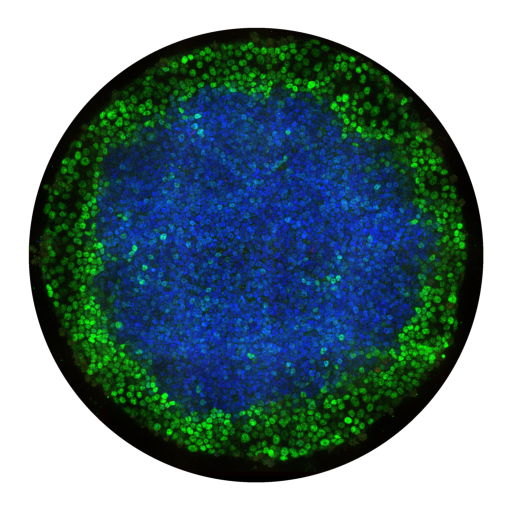

In [43]:
# Render a pseudocolored RGB overlay of raw microscopy images for one Z2 colony, for
# visual inspection / figure panels.

# example channel overlay
colID = 19
#stains = signal_names_simplified 
stains = ['SOX17', 'TFAP2C', 'SOX2_2']
overlay_markers = [None]
for ov in overlay_markers:
    fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
    overlay_marker = ov
    
    RGBbase, image_meta = IIF.makeRGBbase(exp_result_Z2.col, colID, stains, subdataDir, outer_margin=100, crop_margin= 140, center_x_margin = 0, center_y_margin = -0, 
                                Ilim = Ilim, rdStr='Rd')
    
    ax.imshow(RGBbase);
    ax.axis('off');

    import imageio
    #imageio.imwrite(dataDir + f'/B50M0p5_SOX17_TFAP2C_SOX2.png', RGBoverlay)

In [34]:
# Per-channel display percentile ranges used by the multi-condition RGB overlay figure
# below (next cell) -- just image contrast, not related to fate thresholds.

percentiles= {'pSMAD1': [50, 99],
 'YAP': [1, 99.5],
 'BCat': [0.1, 99],
 'LEF1': [1, 99],
 'SMAD23': [1, 99],
 'pERK': [5, 99],
 'pAKT': [10, 99],
 'SMAD2': [1, 99],
 'ISL1': [1, 99],
 'GATA3': [1, 99],
 'HAND1': [1, 99],
 'CDX2': [1, 99],
 'TFAP2C': [1, 99],
 'SOX17': [1, 99],
 'PRDM1': [90, 99.5],
 'SNAI1': [1, 99],
 'MIXL1': [1, 99],
 'EOMES': [1, 99],
 'TBXT': [1, 99],
 'TBX6': [70, 99],
 'OCT4': [1, 99],
 'NANOG': [40, 99],
 'SOX2': [1, 99],
 'SOX2_2': [1, 99],
 'OTX2': [1, 99],
 'DAPI': [1, 99]}

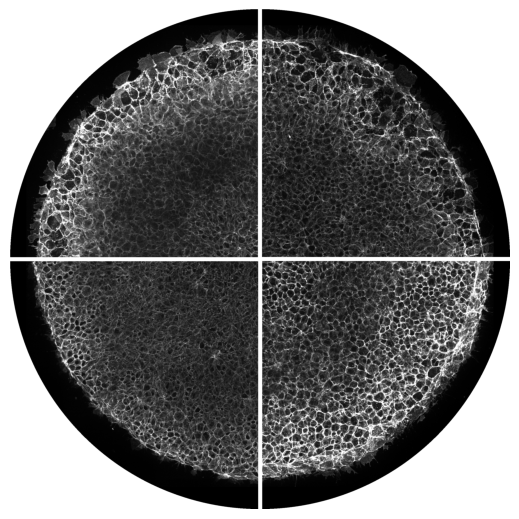

In [44]:
# Build side-by-side RGB overlays comparing colonies from different conditions/
# experiments (BCat channel), for a summary figure panel.

# Plot four-way colony images
overlay_configs = [
    # (col_dict,  col_id, ref_col, center_x_margin, center_y_margin, data_dir)
    (exp_result_Z2.col,  19, 2,  30,   -80,  config.exp_params['Z2'][0]),
    (exp_result_X7.col,   8, 2,   0,    0,   config.exp_params['X7'][0]),
    (exp_result_Z2.col,   8, 2, -30,   40,   config.exp_params['Z2'][0]),
    (exp_result_Z2.col,   2, 2,   0,  -20,   config.exp_params['Z2'][0]),
]

# Unpack for IIF function
cols              = [c[0] for c in overlay_configs]
colis             = [c[1] for c in overlay_configs]
ref_cols          = [c[2] for c in overlay_configs]
center_x_margins  = [c[3] for c in overlay_configs]
center_y_margins  = [c[4] for c in overlay_configs]
dataDirs = [c[5] for c in overlay_configs]


import imageio
import importlib
importlib.reload(IIF)

for marker in ['BCat']:
    RGBoverlay = IIF.makeRGBoverlay_colisectors(
        cols=cols, colis=colis, marker=marker,
        dataDirs=dataDirs,
        crop_margin=70, reference_cols=ref_cols,
        center_x_margins=center_x_margins,
        center_y_margins=center_y_margins,
        percentiles=percentiles,
        outer_margin=80
    )
    
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(RGBoverlay)
    ax.axis('off')
    ax.set_aspect('equal')
    plt.tight_layout(pad=0)
    
    imageio.imwrite(
        dataDir+f'/Fig5/four_cond_overview_{marker}_MIPs.png',
        RGBoverlay
    )
    plt.show()

In [46]:
# Rescale each experiment's radial signaling profiles so the B50 control's own
# min/max map to 0/1. Puts different experiments/conditions on a comparable relative
# scale for the profile plots below, without touching the raw data used elsewhere.

sigs_to_plot = config.signal_names
# Normalize and create experiments
data_norm_Z2, _, _ = IIF.normalize_to_ctrl_profile(
    exp_result_Z2.data_z, exp_result_Z2.exp_z, sigs_to_plot
)
data_norm_X7, _, _ = IIF.normalize_to_ctrl_profile(
    exp_result_X7.data_z, exp_result_X7.exp_z, sigs_to_plot
)

col_norm_Z2, exp_norm_Z2 = IIF.create_experiment(data_norm_Z2, exp_result_Z2.meta, exp_result_Z2.feature_names)
col_norm_X7, exp_norm_X7 = IIF.create_experiment(data_norm_X7, exp_result_X7.meta, exp_result_X7.feature_names)

plot_configs_norm = [
    (exp_norm_Z2, 'B50',     'Z2 ctrl'),
    (exp_norm_Z2, 'B50I5',   'Z2 IWP2'),
    (exp_norm_Z2, 'B50M0p5', 'Z2 MEKi'),
    (exp_norm_X7, 'B50T30',  'X7 TRULI'),
]

B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
B50, Nbins = 544
B50T30, Nbins = 340


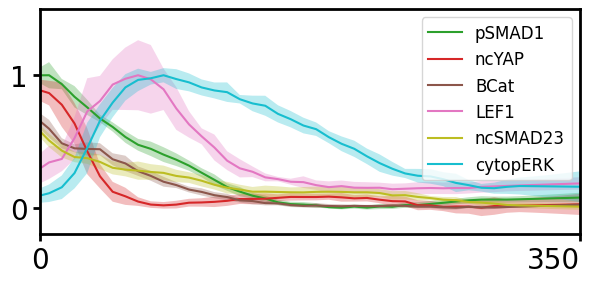

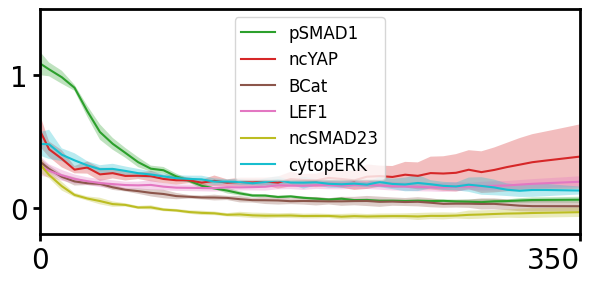

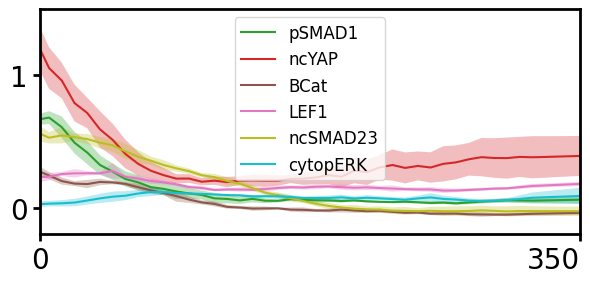

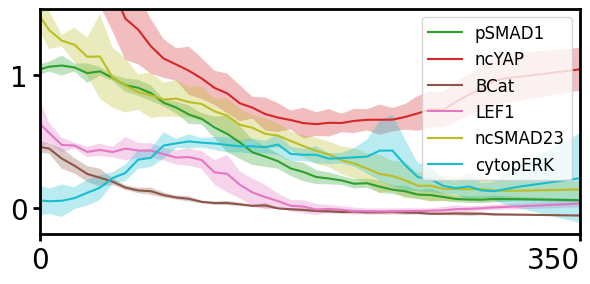

In [50]:
# Plot radial (colony-center-to-edge) profiles of each of the 6 input signals, for the
# B50 control and each perturbation condition, using the profile-normalized data from
# the previous cell.

# Plot signaling profiles
fs = 16
fs_ticks = 20
sw = 2
color_dict = dict(zip(config.signal_names, fns_plot.return_colmaps('signals', N_var=len(config.signal_names))))

for legend in [True]:
    suffix = '_legend' if legend else ''
    
    for exp_norm, cond, label in plot_configs_norm:
        
        fig, ax = plt.subplots(figsize=(6, 3))  # match fate_histogram figsize
        
        handles = []
        for s in sigs_to_plot:
            h = exp_norm.plotRadialProfiles(
                s, cond, mode='colonies', sigma=1,
                color=color_dict[s], ax=ax
            )
            handles.append(h)
        
        ax.set_xlabel('', fontsize=fs)
        ax.set_ylabel('', fontsize=fs)
        ax.set_ylim(-0.2, 1.5)
        
        ax.set_xticks([0, 350])
        ax.set_xticklabels(['0', '350'], fontsize=fs_ticks)
        
        # Center '0' under its tick, right-align '350' under its tick
        ax.xaxis.get_major_ticks()[0].label1.set_horizontalalignment('center')
        ax.xaxis.get_major_ticks()[1].label1.set_horizontalalignment('right')
        ax.set_box_aspect(1/2.4)  # match fate_histogram aspect ratio
        
        for spine in ax.spines.values():
            spine.set_linewidth(sw)
        
        ax.tick_params(axis='x', labelsize=fs_ticks, width=sw, length=5)
        ax.tick_params(axis='y', labelsize=fs_ticks, width=sw, length=5)
        
        y_min, y_max = ax.get_ylim()
        ax.set_yticks(np.arange(int(np.ceil(y_min)), int(np.floor(y_max)) + 1, 1))
        
        if legend:
            ax.legend(handles=handles, labels=sigs_to_plot, fontsize=12)
        
        plt.tight_layout()
        plt.savefig(
            dataDir+f'Fig5/signaling_profiles_{label}{suffix}.png', dpi=150, bbox_inches='tight'
        )
        plt.show()
        plt.close()

In [51]:
# Set up for the naive-vs-KNN SYNTHETIC perturbation comparison below: take Exp20's
# own B50 control data, and also compute a KNN-smoothed version of it (so the 'KNN
# perturbation' constructed later isn't just perturbing noisy single-cell values).

# Load Exp20 data for VIB predictions
exp_result    = exp_result_20
meta_pert     = copy.deepcopy(exp_result.meta)
meta_pert.conditions = ['B50']
hyperparam    = {'HIDDEN_DIM': 32, 'N_LAYERS': 2, 'LATENT_DIM': 2}

PERTURB_KWARGS = dict(
    perturbing_sigs=['cytopERK'], perturb_mode='inh',
    percentile=5, k_nn=5, preserve_signals= ['pSMAD1']
)

# Smooth B50 data
data_B50_20  = exp_result.data[exp_result.data['condition'] == 'B50'].copy()
data_smoothed = data_B50_20.copy()
data_smoothed[exp_result.signal_names] = IIF.apply_smoothing(
    data_B50_20[exp_result.signal_names].values, k_val=10, mode='gaussian'
)

In [52]:
# NOTE: this 'threshold' is UNRELATED to exp_result.thresh (the fate-marker positivity
# cutoffs used elsewhere). IIF.determine_threshold here finds a percentile cutoff on
# the cytopERK SIGNAL (not a gene), identifying cells that are naturally already low
# in cytopERK -- the basis for SIMULATING a MEK inhibitor treatment (perturb_mode=
# 'inh') without any real drug data.
#   'naive' perturbation  = directly set cytopERK to the threshold value for every cell
#   'KNN' perturbation    = project each cell's full signal vector toward its nearest
#                           neighbors among the naturally-low-cytopERK cells, giving a
#                           smoother, more realistic synthetic perturbation

# Thresholds
threshold= IIF.determine_threshold(
    data_B50_20, **{k: PERTURB_KWARGS[k] for k in ['perturbing_sigs', 'perturb_mode', 'percentile']}
)

threshold_smoothed= IIF.determine_threshold(
    data_smoothed, **{k: PERTURB_KWARGS[k] for k in ['perturbing_sigs', 'perturb_mode', 'percentile']}
)
# Naive and KNN perturbations
data_naive, data_naive_z    = IIF.create_perturbed_data(
    data_B50_20,  exp_result.signal_names, PERTURB_KWARGS['perturbing_sigs'],
    threshold, perturb_mode=PERTURB_KWARGS['perturb_mode'], do_naive=True,
    preserve_signals=PERTURB_KWARGS['preserve_signals']
)
data_knn,   data_knn_z   = IIF.create_perturbed_data(
    data_smoothed, exp_result.signal_names, PERTURB_KWARGS['perturbing_sigs'],
    threshold_smoothed, perturb_mode=PERTURB_KWARGS['perturb_mode'], do_naive=False,
    k_nn=PERTURB_KWARGS['k_nn'], preserve_signals=PERTURB_KWARGS['preserve_signals']
)

col_knn_z, exp_knn_z = IIF.create_experiment(data_knn_z, meta_pert, exp_result.feature_names)

B50, Nbins = 609


In [56]:
# Feed the naively-perturbed and KNN-perturbed SYNTHETIC signal data through the
# (already-trained, loaded-from-disk) VIB model trained on Exp20 B50, predicting what
# fate-marker expression -- and therefore what fates -- a MEK inhibitor treatment
# would be predicted to produce, without any real inhibitor experiment.

# Make VIB predictions based on naive and projected signaling
_, avg_pred_naive, predictions_naive = IIF.run_vib_predictions(
    exp_result.exp_dir, data_B50_20, data_naive,
    exp_result.signal_names, exp_result.gene_names, hyperparam, N_run=3
)
_, avg_pred_knn, predictions_knn = IIF.run_vib_predictions(
    exp_result.exp_dir, data_smoothed, data_knn,
    exp_result.signal_names, exp_result.gene_names, hyperparam, N_run=3
)

col_naive_pred, _ = IIF.create_experiment(avg_pred_naive, meta_pert, exp_result.feature_names)
col_knn_pred,   _ = IIF.create_experiment(avg_pred_knn,   meta_pert, exp_result.feature_names)

load VIB
load VIB
load VIB
load VIB
load VIB
load VIB
B50, Nbins = 609
B50, Nbins = 609


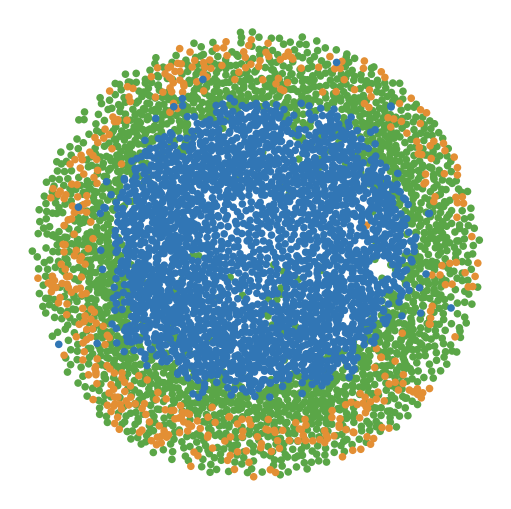

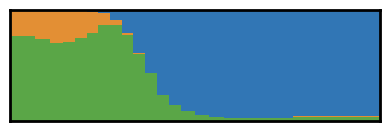

In [58]:
# Compare predicted fate maps for the naive vs. KNN synthetic-perturbation predictions
# from the previous cell.

# Plot colony scatter + fate histogram
do_naive=False

lim = 353
col_id = 2
ms = 30

fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
if do_naive:
    col_naive_pred[col_id].scatter_fates(ms=ms, ax=ax, legend=False, thresh=exp_result_20.thresh)
    filename = dataDir + f'/Fig5/colony_scatter_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_naive.png'
    data_for_hist = avg_pred_naive
    hist_filename = dataDir + f'/Fig5/hist_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_naive.png'
    #mu_perturb = encode_data(vib_choice, data_naive_z, exp_result.signal_names)
else:
    col_knn_pred[col_id].scatter_fates(ms=ms, ax=ax, legend=False, thresh=exp_result_20.thresh)
    filename = dataDir + f'Fig5/colony_scatter_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_knn.png'
    data_for_hist = avg_pred_knn
    hist_filename = dataDir + f'Fig5/hist_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_knn.png'
    #mu_perturb = encode_data(vib_choice, data_knn_z, exp_result.signal_names)
    

plt.savefig(filename) 

IIF.fate_histogram(data_for_hist, exp_result_20)
plt.savefig(hist_filename)

In [ ]:
# Load one specific pretrained sig2fate VIB model (run 12, from the Fig 3 hyperparameter
# sweep) for the latent-space visualizations below.

# Load models from Fig 3
signals = ['pSMAD1', 'ncYAP', 'LEF1', 'BCat', 'ncSMAD23', 'cytopERK']

hyperparam = {'HIDDEN_DIM':32, 'N_LAYERS':2, 'LATENT_DIM': 2}
genes = exp_result_20.gene_names
data = exp_result_20.data

cond = 'B50'
data_cond = data[data['condition']==cond]

feat_train = data_cond[signals] 
tar_train = data_cond[exp_result_20.gene_names]

run = 12
vib = IIF.VIB(feat_train, tar_train, hyperparam)
vib.model = torch.load(
    os.path.join(exp_result_20.exp_dir, f'modelws_12_{len(signals)}D.pth'),
    map_location='cpu', weights_only=False
)
model = vib.model

In [ ]:
# Load the precomputed fate-map grid (latent space -> predicted fate, plus the L1/L2
# axis limits/normalization) generated in Fig 3. Reused here as a fixed background
# reference for comparing where different conditions land in latent space.

# load fate map
dataDir = exp_result_20.exp_dir
L1grid_scaled = np.load(dataDir + '/fatemap_L1grid_scaled.npy')
L2grid_scaled = np.load(dataDir + '/fatemap_L2grid_scaled.npy')
fates = list(np.load(dataDir + '/fatemap_fates.npy'))
L1smin, L1smax, L2smin, L2smax = np.load(dataDir + '/fatemap_limits.npy')
L1mean, L1std = np.load(dataDir + '/fatemap_L1mean_L1std.npy')
L2mean = np.load(dataDir + '/fatemap_L2mean.npy')


do_naive  = True
data_pert = data_naive_z if do_naive else data_knn_z
pert_label = f'naive' if do_naive else f'knn'
filename   = (f'Fig5/LS_fate_{len(exp_result.signal_names)}D_'
              f'{PERTURB_KWARGS["perturbing_sigs"][0]}_'
              f'{PERTURB_KWARGS["perturb_mode"]}_ctrl_vs_{pert_label}.png')

data_z = exp_result_20.data_z

# Encode both B50 and perturbed
with torch.no_grad():
    mu_perturb, _ = vib.model.encode(torch.FloatTensor(data_pert[signals].values))
    mu, _ = vib.model.encode(torch.FloatTensor(data_z[data_z['condition'] == 'B50'][signals].values))
        
mu_perturb  = mu_perturb.numpy()
L1_scaled_perturb = (mu_perturb[:, 0] - L1mean) / L1std
L2_scaled_perturb = (mu_perturb[:, 1] - L2mean) / L1std

mu = mu.numpy()
L1_scaled = (mu[:, 0] - L1mean) / L1std
L2_scaled = (mu[:, 1] - L2mean) / L1std

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

# B50 KDE
kde_grid_b50, levels_b50 = IIF.kde_on_grid(L1_scaled, L2_scaled, L1grid_scaled, L2grid_scaled)
ax.contourf(L1grid_scaled, L2grid_scaled, kde_grid_b50,
           levels=levels_b50, colors='steelblue', alpha=0.2)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_b50,
           levels=levels_b50, colors='steelblue', linewidths=1.5)


# Perturbed KDE
kde_grid_pert, levels_pert = IIF.kde_on_grid(L1_scaled_perturb, L2_scaled_perturb, L1grid_scaled, L2grid_scaled)
ax.contourf(L1grid_scaled, L2grid_scaled, kde_grid_pert,
           levels=levels_pert, colors='coral', alpha=0.2)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_pert,
           levels=levels_pert, colors='coral', linewidths=1.5)


ax.set_xlim(L1smin, L1smax)
ax.set_ylim(L2smin, L2smax)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('Latent Coordinate 1', fontsize=fs)
ax.set_ylabel('Latent Coordinate 2', fontsize=fs)
ax.set_aspect('equal', adjustable='box')

for spine in ax.spines.values():
    spine.set_linewidth(sw)

plt.tight_layout(pad=0.5)
plt.savefig(filename, dpi=150, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [ ]:
# Build the fate-colored background image for the latent-space plots, and encode one
# specific measured perturbation condition (Z2, B50M0p5) into that same latent space,
# for direct visual comparison against the B50 control cloud.

# precompute rgb image once
rgb_image = np.zeros((200, 200, 3))
for i, fate in enumerate(fates):
    color = IIF.colmap_fates[fate]
    rgb_image[i // 200, i % 200] = mcolors.to_rgb(color)



# Encode measured condition
exp_result_meas = ExperimentResults('Z2')
cond = 'B50M0p5'

data_B50_meas = exp_result_meas.data[exp_result_meas.data['condition'] == 'B50'].copy()
data_cond = exp_result_meas.data[exp_result_meas.data['condition'] == cond].copy()
data_cond_z  = exp_result_meas.data_z[exp_result_meas.data_z['condition'] == cond].copy()
mu_meas, _ = vib.model.encode(
    torch.FloatTensor(data_cond_z[signals].values)
)
mu_meas = mu_meas.detach().numpy()

L1_scaled_meas = (mu_meas[:, 0] - L1mean) / L1std
L2_scaled_meas = (mu_meas[:, 1] - L2mean) / L1std

filename = (f'Fig5/LS_fate_{len(exp_result.signal_names)}D_'
            f'{PERTURB_KWARGS["perturbing_sigs"][0]}_'
            f'{PERTURB_KWARGS["perturb_mode"]}_ctrl_vs_meas.png')

# Plot
fs = 26
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rgb_image, origin='lower', extent=[L1smin, L1smax, L2smin, L2smax])

# B50 KDE (white)
kde_grid_b50, levels_b50 = IIF.kde_on_grid(L1_scaled, L2_scaled, L1grid_scaled, L2grid_scaled)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_b50,
           levels=levels_b50, colors='white', linewidths=1.5)

# Measured KDE (black)
kde_grid_meas, levels_meas = IIF.kde_on_grid(L1_scaled_meas, L2_scaled_meas, L1grid_scaled, L2grid_scaled)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_meas,
           levels=levels_meas, colors='black', linewidths=1.5)

ax.set_xlim(L1smin, L1smax)
ax.set_ylim(L2smin, L2smax)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('Latent Coordinate 1', fontsize=fs)
ax.set_ylabel('Latent Coordinate 2', fontsize=fs)
ax.set_aspect('equal', adjustable='box')

for spine in ax.spines.values():
    spine.set_linewidth(sw)

plt.tight_layout(pad=0.5)
plt.savefig(filename, dpi=150, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [ ]:
# Show the ACTUAL measured Z2 B50M0p5 colony's fate calls, using Z2's own manually-
# calibrated exp_result_Z2.thresh. This is the ground truth that the naive/KNN
# synthetic predictions and the real cross-experiment VIB predictions (below) get
# compared against.

# Display experimental data
filename = f'Fig5/colony_scatter_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_exp.png'
hist_filename = f'Fig5/hist_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_exp.png'

# Scatter fates
fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
exp_result_Z2.col[19].scatter_fates(
    ms=ms, ax=ax, legend=False, thresh=exp_result_Z2.thresh
)
plt.savefig(filename) 

IIF.fate_histogram(data_cond, exp_result_Z2)
plt.savefig(hist_filename) 

In [ ]:
# THE MAIN CROSS-EXPERIMENT PREDICTION: train VIB on Exp20's own B50 control data
# only, then predict fate-marker expression for the REAL (not synthetic) Z2 and X7
# perturbation conditions, using signals actually measured in those experiments.
# Tests whether a model that has only ever seen unperturbed control data can still
# predict how real drug perturbations change fate, purely from the six input signals.
# Restricted to common_gene_names since Z2/X7 only measured a 7-gene subset of
# Exp20's 16 genes.

# Training on Exp20, testing on the perturbations
exp_results_list = {'Z2': exp_result_Z2, 'X7': exp_result_X7, '20': exp_result_20}

train_configs = [('20', 'B50')]
test_configs  = [('X7', 'B50T30'), ('Z2', 'B50I5'), ('Z2', 'B50M0p5')]

# Common genes (preserving Exp20 order)
common_gene_names   = [g for g in exp_result_20.gene_names
                       if all(g in exp_res.gene_names
                              for exp_res in exp_results_list.values())]


vib_across, avg_preds, predictions, scalers = IIF.run_vib_across_experiments(
    exp_results_list=exp_results_list,
    train_configs=train_configs,
    test_configs=test_configs,
    signal_names= signals,
    gene_names=common_gene_names,
    hyperparam=hyperparam,
    N_run=3,
    model_path_infix = 'model_across_exp',
    output_prefix='vib_meas_exp20_space'
)

In [ ]:
# Wrap the raw cross-experiment predictions back into Colony/Experiment objects
# (matching each source experiment's own metadata) so they can be plotted the same
# way as measured data.

# Reconstruct exp and col objects from avg_preds

exp_objects = {}
col_objects = {}

for (exp_name, cond), avg_pred in avg_preds.items():
    exp_res = exp_results_list[exp_name]
    
    # Create a copy of meta with the correct condition
    meta = copy.deepcopy(exp_res.meta)
    meta.conditions = [cond]
    
    # Create colony and experiment objects
    col, exp = create_experiment(avg_pred, meta, exp_res.feature_names)
    
    col_objects[(exp_name, cond)] = col
    exp_objects[(exp_name, cond)] = exp
    
    print(f"  {exp_name} {cond}: {len(col)} colonies, {len(avg_pred)} cells")

In [ ]:
# Show the fate map PREDICTED for Z2 B50M0p5 by the Exp20-trained model, for direct
# comparison against the real measured fate map from the 'Display experimental data'
# cell above.

# Display measured signaling predictions based on B50
filename = f'Fig5/colony_scatter_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_meas.png'
hist_filename = f'Fig5/hist_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_meas.png'

# Scatter fates
fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
col_objects[('Z2', 'B50M0p5')][19].scatter_fates(
    ms=ms, ax=ax, legend=False, thresh=exp_result_Z2.thresh
)
plt.savefig(filename) 

IIF.fate_histogram(avg_preds[('Z2', 'B50M0p5')], exp_result_Z2)
plt.savefig(hist_filename) 

In [ ]:
# Build the naive/KNN synthetic perturbation datasets for three different drug
# conditions (MEKi, IWP2/WntSeci-inhibiting, TRULI/LATSi-activating), then compute
# per-cell fate-prediction ENTROPY (uncertainty) in latent space for every real,
# naive-predicted, and KNN-predicted condition. Higher entropy = the model is less
# confident/consistent about which fate a cell belongs to.

# Make entropy plots
perturb_configs = {
    'MEKi':  dict(perturbing_sigs=['cytopERK'], perturb_mode='inh', percentile=5,  k_nn=5, preserve_signals=['pSMAD1']),
    'IWP2':  dict(perturbing_sigs=['LEF1'],     perturb_mode='inh', percentile=0.1, k_nn=5, preserve_signals=['pSMAD1']),
    'TRULI': dict(perturbing_sigs=['ncYAP'],    perturb_mode='act',  percentile=5,   k_nn=5, preserve_signals=None),
}

# Measured conditions
meas_configs = [
    (exp_result_20, 'B50',     'B50'),
    (exp_result_Z2, 'B50M0p5', 'Z2 MEKi'),
    (exp_result_Z2, 'B50I5',   'Z2 IWP2'),
    (exp_result_X7, 'B50T30',  'X7 TRULI'),

naive_data, naive_data_z, knn_data, knn_data_z = {}, {}, {}, {}

for label, kwargs in perturb_configs.items():
    threshold = IIF.determine_threshold(data_B50_20, **{k: kwargs[k] for k in ['perturbing_sigs', 'perturb_mode', 'percentile']})
    threshold_smoothed = IIF.determine_threshold(data_smoothed, **{k: kwargs[k] for k in ['perturbing_sigs', 'perturb_mode', 'percentile']})
    
    naive_data[label], naive_data_z[label] = IIF.create_perturbed_data(
        data_B50_20, exp_result_20.signal_names,
        kwargs['perturbing_sigs'], threshold,
        perturb_mode=kwargs['perturb_mode'], do_naive=True,
        preserve_signals=kwargs['preserve_signals']
    )
    knn_data[label], knn_data_z[label] = IIF.create_perturbed_data(
        data_smoothed, exp_result_20.signal_names,
        kwargs['perturbing_sigs'], threshold_smoothed,
        perturb_mode=kwargs['perturb_mode'], do_naive=False,
        k_nn=kwargs['k_nn'], preserve_signals=kwargs['preserve_signals']
    )


# All datasets to process: (raw_data, z_data, label)
entropy_datasets = (
    [(exp_res.data[exp_res.data['condition'] == cond],
      exp_res.data_z[exp_res.data_z['condition'] == cond], label)
     for exp_res, cond, label in meas_configs] +
    [(naive_data[k],  naive_data_z[k],  f'{label} (naive)') for k, (_, _, label) in zip(perturb_configs, meas_configs[1:])] +
    [(knn_data[k],    knn_data_z[k],    f'{label} (knn)')   for k, (_, _, label) in zip(perturb_configs, meas_configs[1:])]
)

latent_entropy_results = {}

for _, data_cond_z, label in entropy_datasets:
    per_cell, mu_np = IIF.compute_latent_position_entropy(
        vib, data_cond_z,
        signals,
        exp_result_20.gene_names,
        exp_result_20.thresh,
        n_samples=1000
    )
    
    latent_entropy_results[label] = {
        'per_cell': per_cell,
        'L1':       (mu_np[:, 0] - L1mean) / L1std,
        'L2':       (mu_np[:, 1] - L2mean) / L1std,
        'mean':     per_cell.mean()
    }

In [ ]:
# Smoothly interpolate/extrapolate the per-cell B50 entropy values onto a regular
# latent-space grid, for the background entropy map used in the plots below.

from scipy.interpolate import RBFInterpolator

# Extrapolate B50 latent entropy
res      = latent_entropy_results['B50']
points   = np.stack([res['L1'], res['L2']], axis=1)
entropy_vals = res['per_cell'].values

# Grid matching latent space
grid_size   = 200
l1_grid     = np.linspace(L1smin, L1smax, grid_size)
l2_grid     = np.linspace(L2smin, L2smax, grid_size)
L1g, L2g    = np.meshgrid(l1_grid, l2_grid)
grid_points = np.stack([L1g.ravel(), L2g.ravel()], axis=1)

# RBF interpolation/extrapolation
rbf          = RBFInterpolator(points, entropy_vals,
                               kernel='thin_plate_spline', smoothing=0.005)
entropy_grid = rbf(grid_points).reshape(grid_size, grid_size)
entropy_grid = np.clip(entropy_grid, 0, np.log2(len(IIF.colmap_fates)))

In [ ]:
# Custom diverging colormap (clipped RdBu_r) for the entropy heatmaps below.

import matplotlib.colors as mcolors

# Clip RdBu_r
frac_start = 0.2 / 2.2  # = vmin_magnitude / total_range

cmap_clipped = mcolors.LinearSegmentedColormap.from_list(
    'RdBu_r_clipped',
    plt.colormaps['RdBu_r'](np.linspace(frac_start, 1.0, 256))
)

In [ ]:
# For each real experimental condition, overlay its measured latent-space density
# (black contour) on top of the interpolated B50 entropy background -- shows whether
# perturbed/measured cells land in regions the model is more or less confident about.

from mpl_toolkits.axes_grid1 import make_axes_locatable

for exp_res, cond, label in meas_configs:
    
    # Encode measured condition
    data_cond_z       = exp_res.data_z[exp_res.data_z['condition'] == cond]
    mu_meas, _        = vib.model.encode(
        torch.FloatTensor(data_cond_z[signals].values)
    )
    mu_meas           = mu_meas.detach().numpy()
    L1_scaled_meas    = (mu_meas[:, 0] - L1mean) / L1std
    L2_scaled_meas    = (mu_meas[:, 1] - L2mean) / L1std

    # Plot
    fig, ax = plt.subplots(figsize=(5, 6))
    im      = ax.imshow(entropy_grid, origin='lower',
                        extent=[L1smin, L1smax, L2smin, L2smax],
                        cmap=cmap_clipped, vmin=0, vmax=2, aspect='auto', zorder=1)

    # Colorbar on top
    divider = make_axes_locatable(ax)
    cax     = divider.append_axes('top', size='5%', pad=0.05)
    cbar    = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label('Entropy (bits)', fontsize=16, labelpad=-4)
    cbar.ax.tick_params(labelsize=12, length=5, width=2, pad=2)
    cbar.set_ticks([0, 2])
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.xaxis.set_ticks_position('top')
    for spine in cbar.ax.spines.values():
        spine.set_linewidth(sw)

    # Measured KDE
    kde_grid_meas, levels_meas = IIF.kde_on_grid(
        L1_scaled_meas, L2_scaled_meas, L1grid_scaled, L2grid_scaled
    )
    ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_meas,
               levels=levels_meas, colors='black', linewidths=1.5)

    ax.set_xlabel('Latent Coordinate 1', fontsize=fs)
    ax.set_ylabel('Latent Coordinate 2', fontsize=fs)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(L1smin, L1smax)
    ax.set_ylim(L2smin, L2smax)
    ax.set_aspect('equal', adjustable='box')
    for spine in ax.spines.values():
        spine.set_linewidth(sw)

    plt.tight_layout(pad=0.5)
    plt.savefig(
        os.path.join(f'Fig5/LS_entropy_kde_{label.replace(" ", "_")}.png'),
        dpi=150, bbox_inches='tight', pad_inches=0.1
    )
    plt.show()
    plt.close()

In [ ]:
# Summarize mean per-cell entropy across all conditions (real, naive-predicted,
# KNN-predicted) in one comparison plot.

# Plot mean entropy for each predictions
condition_data_dict = {
    'B50':              exp_result_20.data[exp_result_20.data['condition'] == 'B50'],
    'Z2 MEKi':          exp_result_Z2.data[exp_result_Z2.data['condition'] == 'B50M0p5'],
    'Z2 IWP2':          exp_result_Z2.data[exp_result_Z2.data['condition'] == 'B50I5'],
    'X7 TRULI':         exp_result_X7.data[exp_result_X7.data['condition'] == 'B50T30'],
    'Z2 MEKi (naive)':  naive_data['MEKi'],
    'Z2 IWP2 (naive)':  naive_data['IWP2'],
    'X7 TRULI (naive)': naive_data['TRULI'],
    'Z2 MEKi (knn)':    knn_data['MEKi'],
    'Z2 IWP2 (knn)':    knn_data['IWP2'],
    'X7 TRULI (knn)':   knn_data['TRULI'],
}

fig, ax = plot_latent_entropy_comparison(
    latent_entropy_results=latent_entropy_results,
    condition_data_dict=condition_data_dict,
    figsize=(8, 5),
    use_ci=True
)

for spine in ax.spines.values():
    spine.set_linewidth(sw)

ax.tick_params(axis='x', labelsize=fs_ticks, width=sw, length=5)
ax.tick_params(axis='y', labelsize=fs_ticks, width=sw, length=5)
ax.set_yticks([0, 0.3, 0.6, 0.9])
ax.set_yticklabels([]) 

plt.savefig('Fig5/entropy_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Side-by-side fate-pie comparison of naive-predicted, real measured, and KNN-predicted
# colonies for the same perturbation.

fig, ax = IIF.plot_colony_pie_triplet(
    colony_list=[col_naive_pred[2], col_objects[('Z2', 'B50M0p5')][19], col_knn_pred[2]],
    exp_result_list=[exp_result_20, exp_result_Z2, exp_result_20],
    labels=['', '', ''],
    ms=30,           # matches plot_colony_and_histogram default
    start_angle=90,
    boundary_color='white',
    boundary_lw=3,
    #lim = 375
)

plt.savefig(f'Fig5/three_way_colony_plot_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_naive_knn_meas.png') 

In [ ]:
# A SECOND cross-experiment training variant: train JOINTLY on both Exp20's B50
# control AND one real measured Z2 perturbation condition (B50M0p5), rather than
# control-only as in the 'Training on Exp20, testing on the perturbations' cell
# above. Tests whether including some real perturbed data during training improves
# predictions.

# Training on Exp20 and perturbation
exp_results_list = {'Z2': exp_result_Z2, 'X7': exp_result_X7, '20': exp_result_20}

train_configs = [('20', 'B50'),  ('Z2', 'B50M0p5')]
test_configs  = []

# Common genes (preserving Exp20 order)
common_gene_names   = [g for g in exp_result_20.gene_names
                       if all(g in exp_res.gene_names
                              for exp_res in exp_results_list.values())]


vib_joint, avg_preds_joint, predictions_joint, scalers_joint = IIF.run_vib_across_experiments(
    exp_results_list=exp_results_list,
    train_configs=train_configs,
    test_configs=test_configs,
    signal_names= signals,
    gene_names=common_gene_names,
    hyperparam=hyperparam,
    N_run=3,
    model_path_infix = 'model_joint_MEKi',
    output_prefix='vib_joint_meas_exp20_space'
)

In [ ]:
# Same wrapping step as the 'Reconstruct exp and col objects from avg_preds' cell
# above, for the jointly-trained model's predictions.

# Reconstruct exp and col objects from avg_preds_joint
exp_objects_joint = {}
col_objects_joint = {}

for (exp_name, cond), avg_pred_joint in avg_preds_joint.items():
    exp_res = exp_results_list[exp_name]
    
    # Create a copy of meta with the correct condition
    meta = copy.deepcopy(exp_res.meta)
    meta.conditions = [cond]
    
    # Create colony and experiment objects
    col, exp = create_experiment(avg_pred_joint, meta, exp_res.feature_names)
    
    col_objects_joint[(exp_name, cond)] = col
    exp_objects_joint[(exp_name, cond)] = exp
    
    print(f"  {exp_name} {cond}: {len(col)} colonies, {len(avg_pred_joint)} cells")

In [ ]:
# Fate map predicted by the JOINTLY-trained model for Z2 B50M0p5, to compare against
# both the real measurement and the control-only-trained prediction from earlier.

# Display measured signaling predictions based on joint predictions
filename = f'Fig5/colony_scatter_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_meas_joint.png'
hist_filename = f'Fig5/hist_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_meas_joint.png'

# Scatter fates
fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
col_objects_joint[('Z2', 'B50M0p5')][19].scatter_fates(
    ms=ms, ax=ax, legend=False, thresh=exp_result_Z2.thresh
)
plt.savefig(filename) 

IIF.fate_histogram(avg_preds_joint[('Z2', 'B50M0p5')], exp_result_Z2)
plt.savefig(hist_filename) 

In [ ]:
# Build a fresh fate-map background specific to the jointly-trained model's own latent
# space (which differs from the Fig-3 model's latent space loaded earlier), then
# overlay both the B50 control and the real measured perturbation for a final
# side-by-side comparison figure.

# Encode B50 in joint map
vib_joint_choice = vib_joint[0][0]
model     = vib_joint_choice.model


data_z_B50 = exp_result_20.data_z[exp_result_20.data_z['condition'] == 'B50']
X          = torch.FloatTensor(data_z_B50[signals].values).to(device)

model.eval()
with torch.no_grad():
    mu, _ = model.encode(X)

L1, L2         = mu[:, 0].cpu().numpy(), mu[:, 1].cpu().numpy()
L1mean, L1std  = L1.mean(), L1.std()
L2mean         = L2.mean()
L1_scaled      = (L1 - L1mean) / L1std
L2_scaled      = (L2 - L2mean) / L1std

# Axis limits
marg = 0.5
xlim      = (np.percentile(L1_scaled, 0.1) - marg, np.percentile(L1_scaled, 99.9) + marg)
ylim      = (np.percentile(L2_scaled, 0.1) - marg, np.percentile(L2_scaled, 99.9) + marg)
max_range = max(xlim[1] - xlim[0], ylim[1] - ylim[0])
x_center  = (xlim[0] + xlim[1]) / 2
y_center  = (ylim[0] + ylim[1]) / 2

L1smin, L1smax, L2smin, L2smax = (x_center - max_range/2, x_center + max_range/2,
                                y_center - max_range/2, y_center + max_range/2)

# Grid
L1grid_scaled, L2grid_scaled = np.meshgrid(
    np.linspace(L1smin, L1smax, 200),
    np.linspace(L2smin, L2smax, 200)
)
L1grid_raw = L1grid_scaled * L1std + L1mean
L2grid_raw = L2grid_scaled * L1std + L2mean

# Fate map
with torch.no_grad():
    Y_z   = model.decode(torch.FloatTensor(
        np.stack([L1grid_raw.ravel(), L2grid_raw.ravel()], axis=1)
    ).to(device)).cpu().numpy()

Y_fate      = pd.DataFrame(scalers['20']['Y'].inverse_transform(Y_z), columns=common_gene_names)
fates, _    = IIF.return_fates(Y_fate, thresh=exp_result_20.thresh)
fate_colors = np.array([mcolors.to_rgb(IIF.colmap_fates[f]) for f in fates])
rgb_image   = fate_colors.reshape(200, 200, 3)


# Encode measured perturbation
data_meas_z       = exp_result_Z2.data_z[exp_result_Z2.data_z['condition'] == 'B50M0p5']
X_meas            = torch.FloatTensor(data_meas_z[signals].values).to(device)

with torch.no_grad():
    mu_meas, _ = model.encode(X_meas)
mu_meas = mu_meas.cpu().numpy()

L1_scaled_meas = (mu_meas[:, 0] - L1mean) / L1std
L2_scaled_meas = (mu_meas[:, 1] - L2mean) / L1std


# Plot

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rgb_image, origin='lower', extent=[L1smin, L1smax, L2smin, L2smax])

kde_grid_b50,  levels_b50  = IIF.kde_on_grid(L1_scaled,      L2_scaled,      L1grid_scaled, L2grid_scaled)
kde_grid_meas, levels_meas = IIF.kde_on_grid(L1_scaled_meas, L2_scaled_meas, L1grid_scaled, L2grid_scaled)

ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_b50,  levels=levels_b50,  colors='white', linewidths=1.5)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_meas, levels=levels_meas, colors='black', linewidths=1.5)

ax.set_xlabel('Latent Coordinate 1', fontsize=fs)
ax.set_ylabel('Latent Coordinate 2', fontsize=fs)
ax.set_xticks([]);  ax.set_yticks([])
ax.set_xlim(L1smin, L1smax);  ax.set_ylim(L2smin, L2smax)
ax.set_aspect('equal', adjustable='box')

for spine in ax.spines.values():
    spine.set_linewidth(sw)

plt.tight_layout(pad=0.5)
plt.savefig('LS_fate_6D_LEF1_inh_ctrl_vs_meas_joint.png', dpi=150, bbox_inches='tight', pad_inches=0.1)
plt.show()